19-02-2024 11:19:16
0.5607
XRPUSDT - 124
df2 len: 800
peaks_idx: [ 16  96 127 202 243 299 366 413 462 511 559 583 655 714 762]
troughs_idx: [ 53 109 184 220 282 339 377 431 480 534 570 603 694 728]
buy_price: 0.5611364018355843
sell_price: 0.5577577172264013
close price: 0.5574


C:\Users\Dell\AppData\Local\Temp\ipykernel_5992\4114269307.py:99: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df2.close[peaks_idx[-1]])
C:\Users\Dell\AppData\Local\Temp\ipykernel_5992\4114269307.py:115: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("""close price: {}""".format(str(df2.close[-1])))


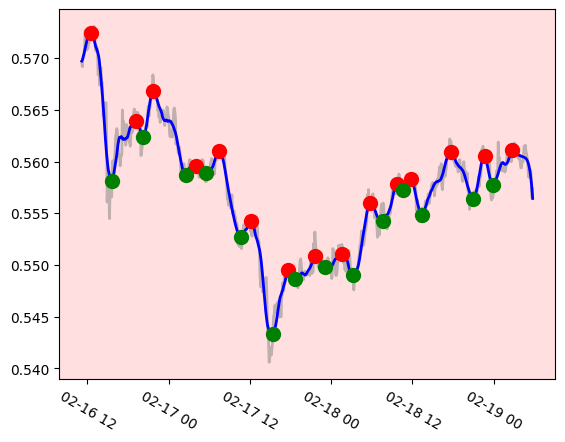

In [ ]:
#!pip install pandas
#!pip install pandas_ta
#!pip install matplotlib
#!pip install scipy
#!pip install python-binance
#%matplotlib inline

import time, gc
import pandas as pd
import pandas_ta as ta
from datetime import datetime, timedelta
from pytz import timezone
from binance.client import Client

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from IPython import display
from IPython.display import HTML, clear_output
pd.set_option('mode.chained_assignment', None)

itr = 1
client = Client("nFkI0vXIipJcEfvBTO6gdaDNpB7QdQozi961siYY3Mnuga5dPpcXZx8UZhfPFO4W", "xPVDaPsJ8wH2G732UWYL2CaegmfUpn5XEOhGJY987BxOQEi3J5keEXKSruWC5kLu")
symbol = 'XRPUSDT'
while True:
    clear_output(wait=True)
    dt_today = datetime.today()  # Local time
    dt_India = dt_today.astimezone(timezone('Asia/Kolkata'))
    start_date = str(datetime.strftime(dt_India, "%d-%m-%Y %H:%M:%S"))
    klines = client.get_historical_klines(symbol, Client.KLINE_INTERVAL_5MINUTE, "3 days ago UTC")
    
    df = pd.DataFrame(klines, columns = ["open_time", "open", "high", "low", "close", "vol", "close_time", "quote_vol",\
                                        "trades", "taker_base_vol", "taker_quote_vol", "ignore"])
    df = df[["open_time", "open", "high", "low", "close"]]
    df["open_time"] = pd.to_datetime(df["open_time"], unit = "ms")
    df["open"] = df.open.astype(float)
    df["high"] = df.open.astype(float)
    df["low"] = df.open.astype(float)
    df["close"] = df.open.astype(float)
    
    df["atr"] = ta.atr(high=df.high, low=df.low, close=df.close)
    df["atr"] = df.atr.rolling(window=30).mean()
    
    df.set_index("open_time", inplace= True)
    dflen = len(df)
    df2 = df.iloc[0:800]
    if dflen > 800:
        dflen = dflen - 800
        df2 = df.iloc[dflen:]
    
    df2["close_smooth"] = savgol_filter(df2.close, 49, 5)
    
    fig, ax = plt.subplots()
    plt.xticks(rotation =-30)
    price = ax.plot(df2.index, df2.close,c='grey', lw=2, alpha=0.5, zorder=5)
    price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)
    
    atr = df2.atr.iloc[-1]
    
    peaks_idx, _ = find_peaks(df2.close_smooth, distance = 15,
                             width = 3, prominence=atr)
    troughs_idx, _ = find_peaks(-1*df2.close_smooth, distance = 15,
                             width = 3, prominence=atr)
    
    peaks, = ax.plot(df2.index[peaks_idx], df2.close_smooth.iloc[peaks_idx], \
                     c="r", linestyle='None', markersize = 10.0, marker = "o", zorder=10)
    troughs, = ax.plot(df2.index[troughs_idx], df2.close_smooth.iloc[troughs_idx], \
                     c="g", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

    up_run_length = 0
    up_run = True
    while up_run:
        if 2 + up_run_length > len(peaks_idx) or 2 + up_run_length > len(troughs_idx):
            break
        if df2.close_smooth.iloc[peaks_idx[-1 - up_run_length]] > df2.close_smooth.iloc[peaks_idx[-2 - up_run_length]] and \
            df2.close_smooth.iloc[troughs_idx[-1 - up_run_length]] > df2.close_smooth.iloc[troughs_idx[-2 - up_run_length]]:
            up_run_length += 1
        else:
            up_run = False
    
    down_run_length = 0
    down_run = True
    while down_run:
        if 2 + down_run_length > len(peaks_idx) or 2 + down_run_length > len(troughs_idx):
            break
        if df2.close_smooth.iloc[peaks_idx[-1 - down_run_length]] > df2.close_smooth.iloc[peaks_idx[-2 - down_run_length]] and \
            df2.close_smooth.iloc[troughs_idx[-1 - down_run_length]] > df2.close_smooth.iloc[troughs_idx[-2 - down_run_length]]:
            down_run_length += 1
        else:
            down_run = False

    print(start_date)
    if int(peaks_idx[-1]) < int(troughs_idx[-1]) and up_run_length > 0:
        ax.set_facecolor((150/255, 255/255, 159/255, 0.3))
        print(df2.close[troughs_idx[-1]])
    elif int(peaks_idx[-1]) > int(troughs_idx[-1]) and down_run_length > 0:
        ax.set_facecolor((255/255, 150/255, 150/255, 0.3))
        print(df2.close[peaks_idx[-1]])
    else:
        ax.set_facecolor("white")
    # if up_run_length > 0:
    #     ax.set_facecolor((150/255, 255/255, 159/255, 0.3))
    # elif down_run_length > 0:
    #     ax.set_facecolor((255/255, 150/255, 150/255, 0.3))
    # else:
    #     ax.set_facecolor("white")

    print('{} - {}'.format(symbol, itr))
    print("""df2 len: {}""".format(str(len(df2))))
    print("""peaks_idx: {}""".format(str(peaks_idx)))
    print("""troughs_idx: {}""".format(str(troughs_idx)))
    print("""buy_price: {}""".format(str(df2.close_smooth.iloc[peaks_idx[-1]])))
    print("""sell_price: {}""".format(str(df2.close_smooth.iloc[troughs_idx[-1]])))
    print("""close price: {}""".format(str(df2.close[-1])))
    plt.show()
    del df
    del df2
    gc.collect()
    itr += 1
    time.sleep(300)